In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
housing = fetch_california_housing(as_frame=True)

In [ ]:
df=housing.frame

In [ ]:
X = df[['AveRooms']].values

In [ ]:
y =df['MedHouseVal'].values.reshape(-1,1)

In [ ]:
X_b =np.c_[np.ones((len(X),1)),X]

In [ ]:
theta_normal =np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [ ]:
y_pred_normal = X_b @ theta_normal

In [ ]:
print("---normal equation--")
print("intercept:",theta_normal[0][0])
print("slope :",theta_normal[1][0])
print("MSE :",mean_squared_error(y,y_pred_normal))
print("R2 Score :",r2_score(y,y_pred_normal))

---normal equation--
intercept: 1.6838115086404832
slope : 0.0708687932804052
MSE : 1.3008070902505424
R2 Score : 0.023088282755354017


In [ ]:
def compute_cost(X,y,theta):
  m=len(y)
  predictions=X@theta
  cost=(1/(2*m)) * np.sum((predictions-y)*2)
  return cost

In [ ]:
def gradient_descent(X,y,theta,learning_rate,iterations):
  m=len(y)
  cost_history=[]
  for i in range(iterations):
   gradients=(1/m)*X.T@(X@theta-y)
   theta=theta-learning_rate*gradients
   cost_history.append(compute_cost(X,y,theta))
  return theta,cost_history

In [ ]:
theta=np.zeros((2,1))
learning_rate=0.001
iterations=1000
theta_gd,cost_history=gradient_descent(X_b,y,theta,learning_rate,iterations)
y_pred_gd=X_b@theta_gd

In [ ]:
print("\n-----Gradient Descent---")
print("intercept:",theta_gd[0][0])
print("Slope :",theta_gd[1][0])
print("MSE :",mean_squared_error(y,y_pred_gd))
print("R2 Score :",r2_score(y,y_pred_gd))


-----Gradient Descent---
intercept: 0.30209997653075465
Slope : 0.2826073529823789
MSE : 1.6291507228490774
R2 Score : -0.22349919695034104


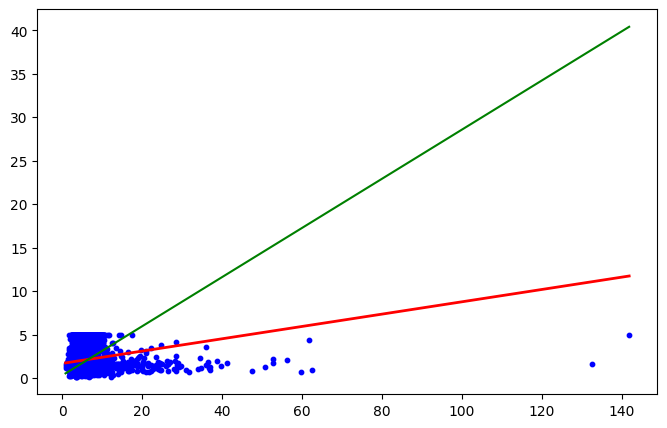

In [ ]:
import numpy as np
sort_index=np.argsort(X.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X,y,s=10,color='blue',label='Actual Data')
plt.plot(X[sort_index],y_pred_normal[sort_index],color='red',linewidth=2,label='Normal Equation')
plt.plot(X[sort_index],y_pred_gd[sort_index],color='green',label='Gradient Descent')


/tmp/ipykernel_905/4181010214.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


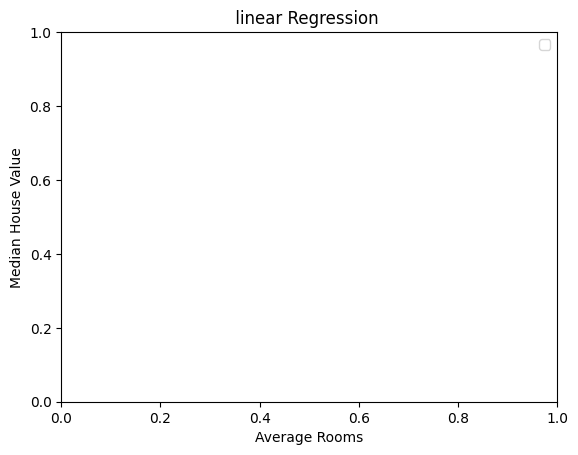

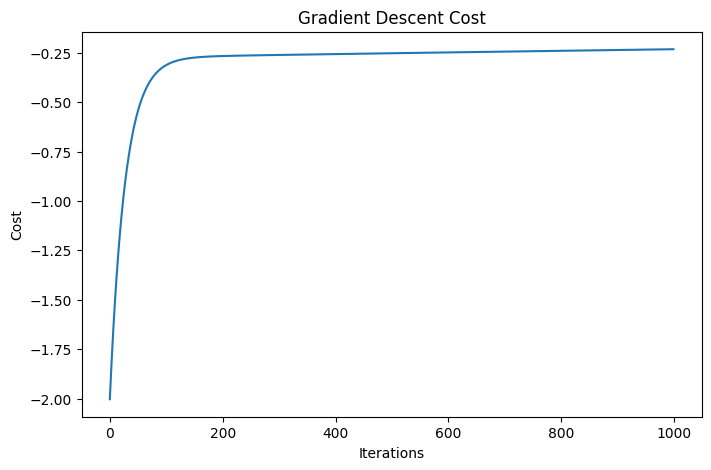

In [ ]:
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.title(" linear Regression  ")
plt.legend()
plt.show()
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Cost")
plt.show()